# GuitarMidi-LV2 Library
 # Copyright (C) 2026 Gerald Mwangi
 #
 # This program is free software; you can redistribute it and/or
 # modify it under the terms of the GNU Lesser General Public
 # License as published by the Free Software Foundation; either
 # version 2 of the License, or (at your option) any later version.
 #
 # This program is distributed in the hope that it will be useful,
 # but WITHOUT ANY WARRANTY; without even the implied warranty of
 # MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU
 # Lesser General Public License for more details.
 #
 # You should have received a copy of the GNU Lesser General
 # Public License along with this program; if not, write to the
 # Free Software Foundation, Inc., 51 Franklin Street, Fifth Floor,
 # Boston, MA  02110-1301  USA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
def softmax_entropy_report(model, sample_input, string_layer_names):
    if isinstance(sample_input, tf.data.Dataset):
        for batch in sample_input.take(1):
            sample_input = batch[0] if isinstance(batch, (tuple, list)) else batch
            break

    for name in string_layer_names:
        layer = model.get_layer(name)
        intermediate = tf.keras.Model(inputs=model.input, outputs=layer.output)
        probs = intermediate(sample_input, training=False).numpy()  # (batch, 14)
        eps = 1e-8
        entropy = -np.sum(probs * np.log(probs + eps), axis=-1)  # (batch,)
        max_entropy = np.log(probs.shape[-1])
        print(f"{name}: mean entropy={entropy.mean():.3f} "
              f"({entropy.mean()/max_entropy*100:.1f}% of max={max_entropy:.3f})")

def plot_active_neurons(model, sample_input, active_threshold=0.0, batch_agg='mean'):
    """
    Plot number of active neurons (output > active_threshold) per layer.

    sample_input: numpy array or tensor of shape (batch_size, ...) - accepts batches
    active_threshold: value above which a neuron is considered "active"
    batch_agg: how to aggregate activity across the batch dimension:
        'mean' -> average fraction of batch samples that activate each neuron,
                  then average over neurons (soft ratio)
        'any'  -> a neuron counts as active if ANY sample in the batch activates it
        'all'  -> a neuron counts as active only if ALL samples activate it
    """
    if isinstance(sample_input, tf.data.Dataset):
        for batch in sample_input.take(1):
            # handle (audio, label) tuples vs plain audio batches
            sample_input = batch[0] if isinstance(batch, (tuple, list)) else batch
            break

    sample_input = np.asarray(sample_input)
    if sample_input.ndim == 0:
        raise ValueError("sample_input must have a batch dimension")

    batch_size = sample_input.shape[0]

    layer_names = []
    active_counts = []
    active_ratios = []
    total_counts = []

    for layer in model.layers:
        try:
            intermediate = tf.keras.Model(inputs=model.input, outputs=layer.output)
            out = intermediate(sample_input, training=False)
            out_np = out.numpy()

            # Flatten everything except the batch dimension: (batch, neurons)
            out_flat = out_np.reshape(batch_size, -1)
            n_neurons = out_flat.shape[1]

            # Per-neuron, per-sample activity mask
            active_mask = out_flat > active_threshold  # shape (batch, neurons)

            if batch_agg == 'mean':
                per_neuron_frac = active_mask.mean(axis=0)  # (neurons,)
                active = per_neuron_frac.sum()
                ratio = per_neuron_frac.mean()
            elif batch_agg == 'any':
                neuron_active = active_mask.any(axis=0)
                active = neuron_active.sum()
                ratio = active / n_neurons if n_neurons > 0 else 0
            elif batch_agg == 'all':
                neuron_active = active_mask.all(axis=0)
                active = neuron_active.sum()
                ratio = active / n_neurons if n_neurons > 0 else 0
            else:
                raise ValueError(f"Unknown batch_agg: {batch_agg}")

            layer_names.append(layer.name)
            active_counts.append(active)
            total_counts.append(n_neurons)
            active_ratios.append(ratio)
        except Exception as e:
            print(f"Skipping layer {layer.name}: {e}")

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    colors = ['green' if r >= 0.65 else 'orange' if r >= 0.4 else 'red'
              for r in active_ratios]

    x = np.arange(len(layer_names))

    ax1.bar(x, active_counts, color=colors)
    ax1.set_ylabel('Active Neuron Count', fontsize=8)
    ax1.set_title(
        f'Active Neurons per Layer (output > {active_threshold}, batch_agg="{batch_agg}", batch_size={batch_size})',
        fontsize=9
    )
    ax1.tick_params(axis='y', labelsize=6)
    for i, (a, t) in enumerate(zip(active_counts, total_counts)):
        ax1.text(i, a + 0.5, f'{a:.1f}/{t}', ha='center', va='bottom', fontsize=4, rotation=90)

    ax2.bar(x, active_ratios, color=colors)
    ax2.set_ylabel('Active Ratio', fontsize=8)
    ax2.set_ylim(0, 1)
    ax2.axhline(0.65, color='green', linestyle='--', linewidth=1, label='65% threshold')
    ax2.axhline(0.4, color='orange', linestyle='--', linewidth=1, label='40% threshold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(layer_names, rotation=90, fontsize=5)
    ax2.tick_params(axis='y', labelsize=6)
    ax2.legend(fontsize=6)

    plt.tight_layout()
    plt.savefig('active_neurons.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to active_neurons.png")


def visualize_model_weights(model, save_dir='weight_plots', show=True):
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    os.makedirs(save_dir, exist_ok=True)

    for layer in model.layers:
        weights = layer.get_weights()
        if not weights:
            continue

        w = weights[0]
        name = layer.name

        if w.ndim == 4:
            n_filters = w.shape[-1]
            cols = min(8, n_filters)
            rows = (n_filters + cols - 1) // cols
            fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
            axes = np.array(axes).flatten()
            for i in range(n_filters):
                kernel = w[:, :, :, i].sum(axis=-1) if w.shape[2] > 1 else w[:, :, 0, i]
                axes[i].imshow(kernel, cmap='RdBu_r', aspect='auto')
                axes[i].set_title(f'F{i}', fontsize=8)
                axes[i].axis('off')
            for i in range(n_filters, len(axes)):
                axes[i].axis('off')
            fig.suptitle(f'{name} (Conv2D) — Filter Heatmaps\n{w.shape}', fontsize=10)
            fig.tight_layout()
            fig.savefig(os.path.join(save_dir, f'{name}_heatmaps.png'), dpi=150)
            if show:
                plt.show()
            plt.close(fig)

        elif w.ndim == 3:
            fig, ax = plt.subplots(figsize=(10, 4))
            reshaped = w.reshape(-1, w.shape[-1])
            im = ax.imshow(reshaped.T, cmap='RdBu_r', aspect='auto')
            ax.set_xlabel('Kernel × Input Channels')
            ax.set_ylabel('Output Filters')
            ax.set_title(f'{name} (Conv1D) — {w.shape}')
            plt.colorbar(im, ax=ax)
            fig.tight_layout()
            fig.savefig(os.path.join(save_dir, f'{name}.png'), dpi=150)
            if show:
                plt.show()
            plt.close(fig)

        elif w.ndim == 2:
            fig, ax = plt.subplots(figsize=(10, 6))
            im = ax.imshow(w, cmap='RdBu_r', aspect='auto')
            ax.set_xlabel('Output Units')
            ax.set_ylabel('Input Units')
            ax.set_title(f'{name} (Dense) — {w.shape}')
            plt.colorbar(im, ax=ax)
            fig.tight_layout()
            fig.savefig(os.path.join(save_dir, f'{name}.png'), dpi=150)
            if show:
                plt.show()
            plt.close(fig)

        fig, ax = plt.subplots(figsize=(6, 3))
        ax.hist(w.flatten(), bins=100, color='steelblue', edgecolor='none')
        ax.set_title(f'{name} — Weight Distribution (mean={w.mean():.4f}, std={w.std():.4f})')
        ax.axvline(0, color='red', linestyle='--', alpha=0.5)
        fig.tight_layout()
        fig.savefig(os.path.join(save_dir, f'{name}_hist.png'), dpi=150)
        if show:
            plt.show()
        plt.close(fig)

def plot_all_layer_activations(model, x_sample):
    """Plot activations of ALL layers for a single sample.
    
    Args:
        model: trained keras model
        x_sample: input tensor, shape (1, timesteps, features)
    """
    # Skip input layer
    layer_outputs = []
    layer_names = []
    
    for layer in model.layers:
        if layer.__class__.__name__ == 'InputLayer':
            continue
        try:
            sub_model = tf.keras.Model(inputs=model.input, outputs=layer.output)
            act = sub_model.predict(x_sample, verbose=0)
            layer_outputs.append(act)
            layer_names.append(f"{layer.name} ({layer.__class__.__name__})")
        except Exception as e:
            print(f"Skipping {layer.name}: {e}")
    
    n = len(layer_outputs)
    fig, axes = plt.subplots(n, 1, figsize=(16, 2.5 * n))
    if n == 1:
        axes = [axes]
    
    for ax, act, name in zip(axes, layer_outputs, layer_names):
        act = np.squeeze(act, axis=0)  # remove batch dim
        
        if act.ndim == 3:
            # (H, W, C) or similar — flatten to 2D
            h, w, c = act.shape
            act_2d = act.reshape(h * w, c)
            im = ax.imshow(act_2d.T, aspect='auto', interpolation='nearest', cmap='viridis')
            ax.set_ylabel('Channel')
            ax.set_xlabel('Spatial (flattened)')
            plt.colorbar(im, ax=ax, fraction=0.02)
        elif act.ndim == 2:
            # (time, channels)
            im = ax.imshow(act.T, aspect='auto', interpolation='nearest', cmap='viridis')
            ax.set_ylabel('Channel')
            ax.set_xlabel('Time')
            plt.colorbar(im, ax=ax, fraction=0.02)
        elif act.ndim == 1:
            # dense / output
            ax.bar(range(len(act)), act, width=1.0, edgecolor='none')
            ax.set_xlabel('Unit')
            ax.set_ylabel('Activation')
            ax.set_xlim(-0.5, len(act) - 0.5)
        elif act.ndim == 0:
            ax.text(0.5, 0.5, f"Scalar: {float(act):.6f}", 
                    transform=ax.transAxes, ha='center', va='center', fontsize=14)
        else:
            # 4D+ — take mean over extra dims
            while act.ndim > 2:
                act = act.mean(axis=0)
            im = ax.imshow(act.T if act.ndim == 2 else act[np.newaxis, :], 
                          aspect='auto', cmap='viridis')
            plt.colorbar(im, ax=ax, fraction=0.02)
        
        # Add stats to title
        act_flat = np.squeeze(act).flatten()
        stats = f"min={act_flat.min():.3f} max={act_flat.max():.3f} mean={act_flat.mean():.3f} std={act_flat.std():.3f}"
        ax.set_title(f"{name}  shape={np.squeeze(act).shape}  [{stats}]", fontsize=9)
    
    plt.tight_layout()
    plt.savefig("all_layer_activations.png", dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Plotted {n} layers. Saved all_layer_activations.png")


# Usage:
#plot_all_layer_activations(cnn_model, x)



I0000 00:00:1784747191.930810 1681757 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784747191.957223 1681757 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784747193.425961 1681757 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.data import TFRecordDataset 
import numpy as np
import os
import matplotlib.pyplot as plt
from common import fast_gpu_map,SAMPLERATE,feature_description,parse_filtered_audio_record,filter_polyphony
import glob
import re
from model import build_1d_cnn_model
import common
BATCH_SIZE=1000
#input_data_dir = '/data2/training_subset_acoustic'
input_data_dir='/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset_test'
input_filepaths = sorted(glob.glob(os.path.join(input_data_dir, '**', '*.tfrecord'), recursive=True),key=lambda file: int(re.findall('\\d+',os.path.basename(file))[0]) )
#model_weights="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/checkpoints/guitarmidi_epoch231_valAcc0.9737_valPrec0.8053_valRecall0.6572.h5"#
#model_weights="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/checkpoints/guitarmidi_epoch232_valAcc0.9744_valPrec0.8160_valRecall0.6597.h5"#
model_weights="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/checkpoints/guitarmidi_epoch233_valAcc0.9767_valPrec0.8449_valRecall0.6783.h5"#
model_weights="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/checkpoints/guitarmidi_smooth_chord_dist_epoch09_valAcc0.9806_valPrec0.8344_valRecall0.6417.keras"#
#model_weights="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/guitarmidi.keras"

cnn_model=build_1d_cnn_model(BATCH_SIZE,common.INPUT_SHAPE,37,training=False)# common.OUTPUT_DIM_NOTES,training=False)
cnn_model.load_weights(model_weights)
dataset=TFRecordDataset(input_filepaths)

# Parse the dataset
dataset = dataset.map(parse_filtered_audio_record).shuffle(buffer_size=10000,reshuffle_each_iteration=False)
#dataset_orig=dataset.map(lambda inp,out: fast_gpu_map(inp,out,training=False)).batch(BATCH_SIZE,drop_remainder=True).take(500).prefetch(tf.data.AUTOTUNE)
dataset_orig=dataset.map(lambda inp,out: fast_gpu_map(inp,out,training=False)).batch(BATCH_SIZE,drop_remainder=True).prefetch(tf.data.AUTOTUNE)
dataset=dataset_orig.take(500)
# Get raw sigmoid probabilities from your model
val_preds_probs = cnn_model.predict(dataset)
val_labels_list = []
for features, labels in dataset:
    labels = labels.numpy()
    # print(labels.shape,flush=True)
    val_labels_list.append(labels[:,0:37])
    
val_labels = np.concatenate(val_labels_list, axis=0)

# Test thresholds from 0.1 to 0.9
for thresh in np.arange(0.1, 1.0, 0.1):
    preds = (val_preds_probs > thresh).astype(int)
    
    p = precision_score(val_labels.flatten(), preds.flatten())
    r = recall_score(val_labels.flatten(), preds.flatten())
    f1 = f1_score(val_labels.flatten(), preds.flatten())
    
    print(f"Threshold: {thresh:.1f} | Precision: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f}")


Image height:  148
Before string split: (1000, 148, 512), max_x=148.0
String slice ranges (in time steps):  [(0, 52), (20, 72), (40, 92), (60, 112), (76, 128), (96, 148)]
String 0: slicing from 0 to 52 (max_x=148.0)
String 1: slicing from 20 to 72 (max_x=148.0)
String 2: slicing from 40 to 92 (max_x=148.0)
String 3: slicing from 60 to 112 (max_x=148.0)
String 4: slicing from 76 to 128 (max_x=148.0)
String 5: slicing from 96 to 148 (max_x=148.0)
After string split:  [(1000, 13, 64), (1000, 13, 64), (1000, 13, 64), (1000, 13, 64), (1000, 13, 64), (1000, 13, 64)]


I0000 00:00:1784747195.684990 1682515 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


323/323 ━━━━━━━━━━━━━━━━━━━━ 220s 677ms/step


/home/gerald/anaconda3/envs/cpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Threshold: 0.1 | Precision: 0.443 | Recall: 0.848 | F1: 0.582
Threshold: 0.2 | Precision: 0.629 | Recall: 0.781 | F1: 0.697
Threshold: 0.3 | Precision: 0.712 | Recall: 0.739 | F1: 0.725
Threshold: 0.4 | Precision: 0.774 | Recall: 0.705 | F1: 0.738
Threshold: 0.5 | Precision: 0.819 | Recall: 0.673 | F1: 0.739
Threshold: 0.6 | Precision: 0.857 | Recall: 0.639 | F1: 0.732
Threshold: 0.7 | Precision: 0.890 | Recall: 0.602 | F1: 0.718
Threshold: 0.8 | Precision: 0.924 | Recall: 0.557 | F1: 0.695
Threshold: 0.9 | Precision: 0.957 | Recall: 0.488 | F1: 0.647


In [3]:
from sklearn.metrics import precision_recall_curve
import numpy as np

dataset = dataset_orig#filter_polyphony(dataset_orig.unbatch(), 6, True, start_note=0, end_note=37, has_filtered_audio=True).batch(BATCH_SIZE, drop_remainder=True)

audio, label = None, None
element_idx = 1
for idx, (audio_batch, label_batch) in enumerate(dataset):
    if idx == element_idx:
        print(f"Selected element index: {idx}")
        x = audio_batch
        y_true = label_batch
        break

# get probs and true labels over a validation batch
probs = cnn_model.predict(x)          # (N, 37) numpy array already
y_true = y_true.numpy()               # <-- fix: convert EagerTensor to numpy

precisions, recalls, thresholds = precision_recall_curve(y_true.ravel(), probs.ravel())
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx = f1s.argmax()
print(f"best threshold={thresholds[best_idx]:.3f}, "
      f"precision={precisions[best_idx]:.3f}, recall={recalls[best_idx]:.3f}, f1={f1s[best_idx]:.3f}")

Selected element index: 1
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step
best threshold=0.475, precision=0.825, recall=0.712, f1=0.764


In [4]:
import numpy as np
import tensorflow as tf
from chordanalysishistogram import build_chord_suffix_histogram_fast, print_histogram
from guitarchordanalyzer import GuitarChordAnalyzer

THRESHOLD = 0.71          # from your precision_recall_curve result
LOWEST_MIDI = 40          # <-- set this to whatever MIDI note your index 0 represents

predictions = []
audios = []
subset=dataset.take(100)  # take a subset for speed
for audio, label in subset:
    pred = cnn_model.predict(audio, verbose=0)
    predictions.append(pred)
    audios.append(audio)

probs = np.concatenate(predictions, axis=0)   # (N, 37)

# binarize with your tuned threshold
binary_preds = (probs > THRESHOLD).astype(np.float32)   # (N, 37)

# build a 129-dim multi-hot label per frame: MIDI notes 0-127 + silence flag
N = binary_preds.shape[0]
full_labels = np.zeros((N, 129), dtype=np.float32)
for i in range(37):
    midi_note = LOWEST_MIDI + i
    full_labels[:, midi_note] = binary_preds[:, i]

# mark silence where no notes at all are active
no_notes = binary_preds.sum(axis=1) == 0
full_labels[no_notes, 128] = 1.0

# fabricate matching audio_path / frame_nr placeholders since the histogram
# function expects a 3-tuple (audio_path, frame_nr, label)
fake_audio_path = np.zeros((N,), dtype=np.int32)
fake_frame_nr   = np.arange(N, dtype=np.int32)

dataset_viz = tf.data.Dataset.from_tensor_slices(
    (fake_audio_path, fake_frame_nr, full_labels)
).batch(BATCH_SIZE, drop_remainder=True)
print(f"Prepared dataset_viz with {N} frames for histogram visualization.")
histogram = build_chord_suffix_histogram_fast(dataset_viz, GuitarChordAnalyzer)
print("histogram for dataset_viz:")
print_histogram(histogram, top_n=30)





import tensorflow as tf

LOWEST_MIDI = 40  # verify against your actual note-index mapping

def expand_label_to_129(label37):
    # works whether label37 is (37,) or (batch, 37)
    label37 = tf.cast(label37, tf.float32)
    is_batched = label37.shape.rank == 2

    indices = tf.range(37, dtype=tf.int64) + LOWEST_MIDI  # (37,)

    if is_batched:
        batch_size = tf.shape(label37)[0]
        label129 = tf.zeros([batch_size, 129], dtype=tf.float32)
        # scatter along axis=1 for each row
        batch_idx = tf.range(batch_size, dtype=tf.int64)
        bb, ii = tf.meshgrid(batch_idx, indices, indexing='ij')  # (batch,37)
        scatter_idx = tf.stack([bb, ii], axis=-1)                # (batch,37,2)
        label129 = tf.tensor_scatter_nd_update(
            label129, tf.reshape(scatter_idx, [-1, 2]),
            tf.reshape(label37, [-1])
        )
        is_silent = tf.reduce_sum(label37, axis=1) == 0          # (batch,)
        silent_idx = tf.stack([batch_idx, tf.fill([batch_size], tf.constant(128, dtype=tf.int64))], axis=1)
        label129 = tf.tensor_scatter_nd_update(
            label129, silent_idx, tf.cast(is_silent, tf.float32)
        )
    else:
        label129 = tf.zeros([129], dtype=tf.float32)
        label129 = tf.tensor_scatter_nd_update(
            label129, tf.expand_dims(indices, 1), label37
        )
        is_silent = tf.reduce_sum(label37) == 0
        label129 = tf.tensor_scatter_nd_update(
            label129, [[128]], [tf.cast(is_silent, tf.float32)]
        )

    return label129


def add_fake_frame_nr(audio, label):
    label129 = expand_label_to_129(label)
    # if batched, frame_nr needs to be a batch-shaped tensor too
    if label.shape.rank == 2:
        batch_size = tf.shape(label)[0]
        fake_frame_nr = tf.zeros([batch_size], dtype=tf.int64)
        fake_audio_path = tf.zeros([batch_size], dtype=tf.int64)  # if audio_path also expected as batch-scalar
    else:
        fake_frame_nr = tf.constant(0, dtype=tf.int64)
        fake_audio_path = tf.constant(0, dtype=tf.int64)
    return audio, fake_frame_nr, label129


def expand_label_only(audio, frame_nr, label):
    label129 = expand_label_to_129(label)
    return audio, frame_nr, label129

subset_expanded = subset.map(expand_label_only)

histogram = build_chord_suffix_histogram_fast(subset_expanded, GuitarChordAnalyzer)
print("histogram for true labels:")
print_histogram(histogram, top_n=30)



Prepared dataset_viz with 100000 frames for histogram visualization.
Building pitch-class -> suffix lookup table (one-time cost)...
Lookup table built: 12288 entries.
Total frames:            100000
Skipped (silent):        53478
Skipped (note count):    0
Skipped (unrecognized):  6
Chords counted:          46516
histogram for dataset_viz:
9                  42388  (91.13%)
major6              1295  ( 2.78%)
sus4_7               820  ( 1.76%)
major                699  ( 1.50%)
minor                376  ( 0.81%)
augmented            258  ( 0.55%)
minor9               168  ( 0.36%)
7b9                  162  ( 0.35%)
major9                74  ( 0.16%)
diminished7           62  ( 0.13%)
sus2                  59  ( 0.13%)
no3_add4              45  ( 0.10%)
minor6                39  ( 0.08%)
sus2_7                23  ( 0.05%)
minor7                22  ( 0.05%)
7#9                    7  ( 0.02%)
major7                 6  ( 0.01%)
dominant7              5  ( 0.01%)
add9                   4  ( 

TypeError: in user code:


    TypeError: outer_factory.<locals>.inner_factory.<locals>.tf__expand_label_only() missing 1 required positional argument: 'label'


In [ ]:
subset_expanded = subset.map(expand_label_only)

histogram = build_chord_suffix_histogram_fast(subset_expanded, GuitarChordAnalyzer)
print("histogram for true labels:")
print_histogram(histogram, top_n=30)

TypeError: in user code:


    TypeError: outer_factory.<locals>.inner_factory.<locals>.tf__expand_label_only() missing 1 required positional argument: 'label'


Collected shape: (323000, 37)


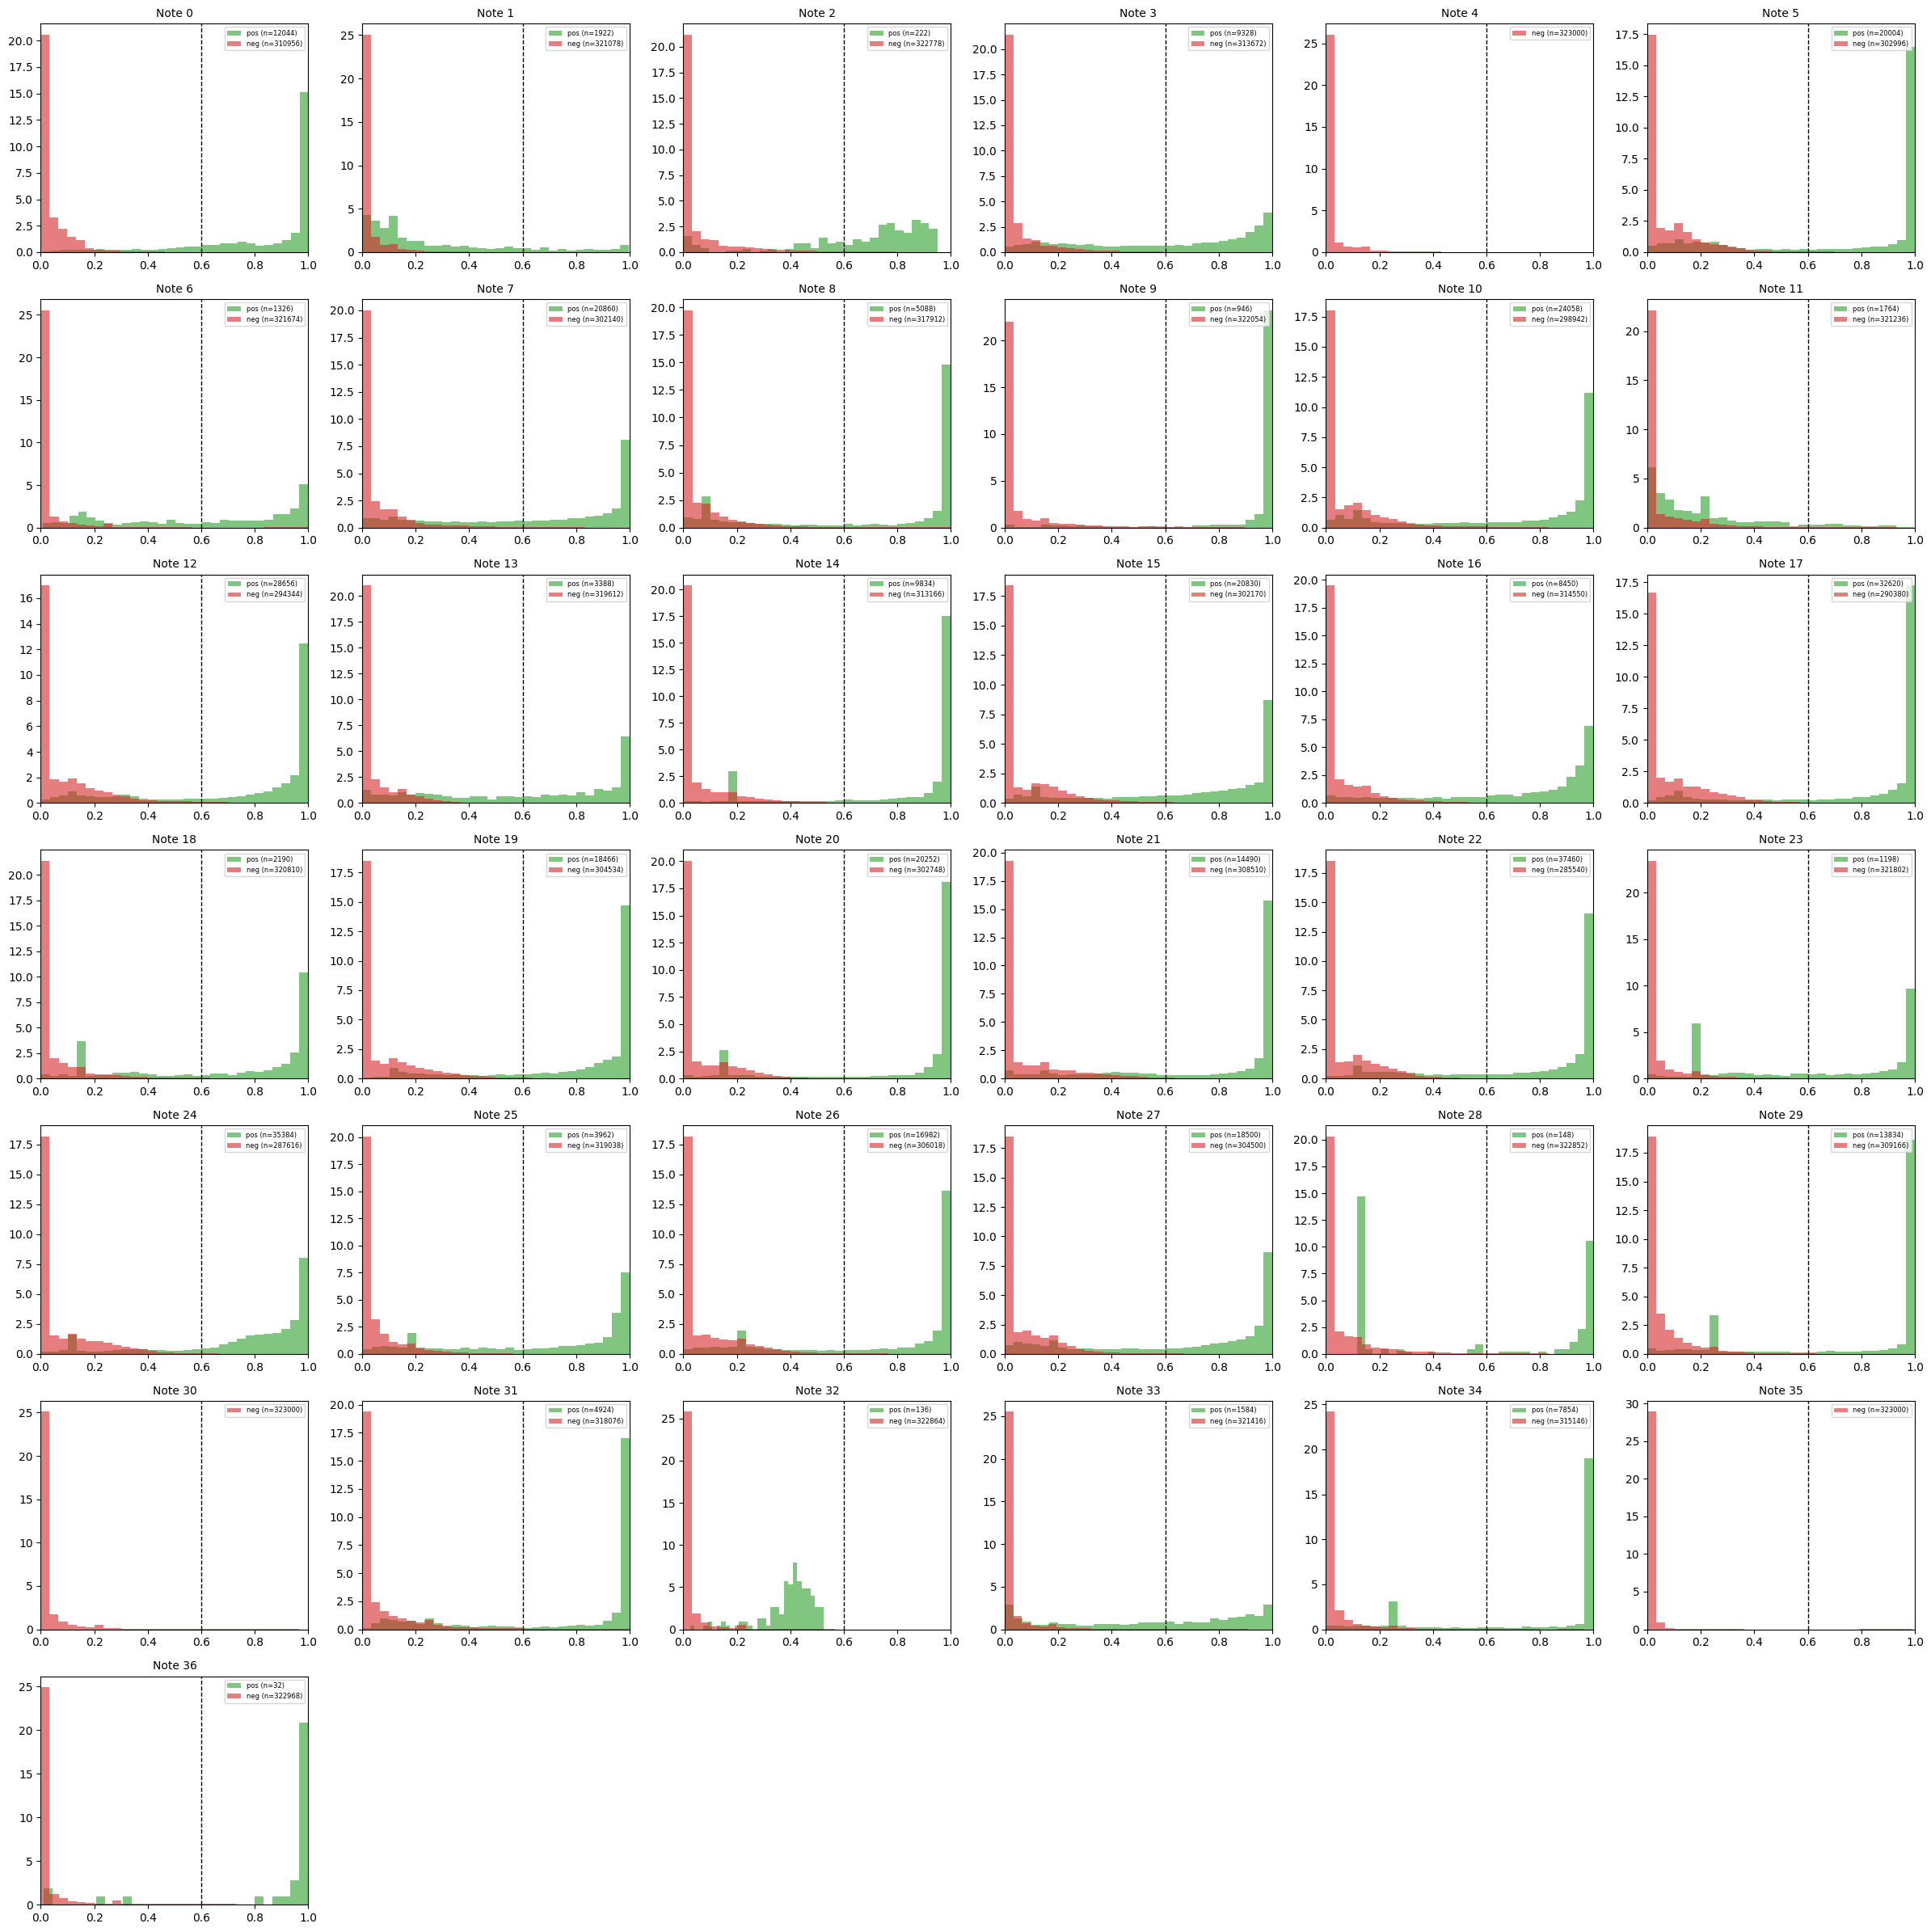

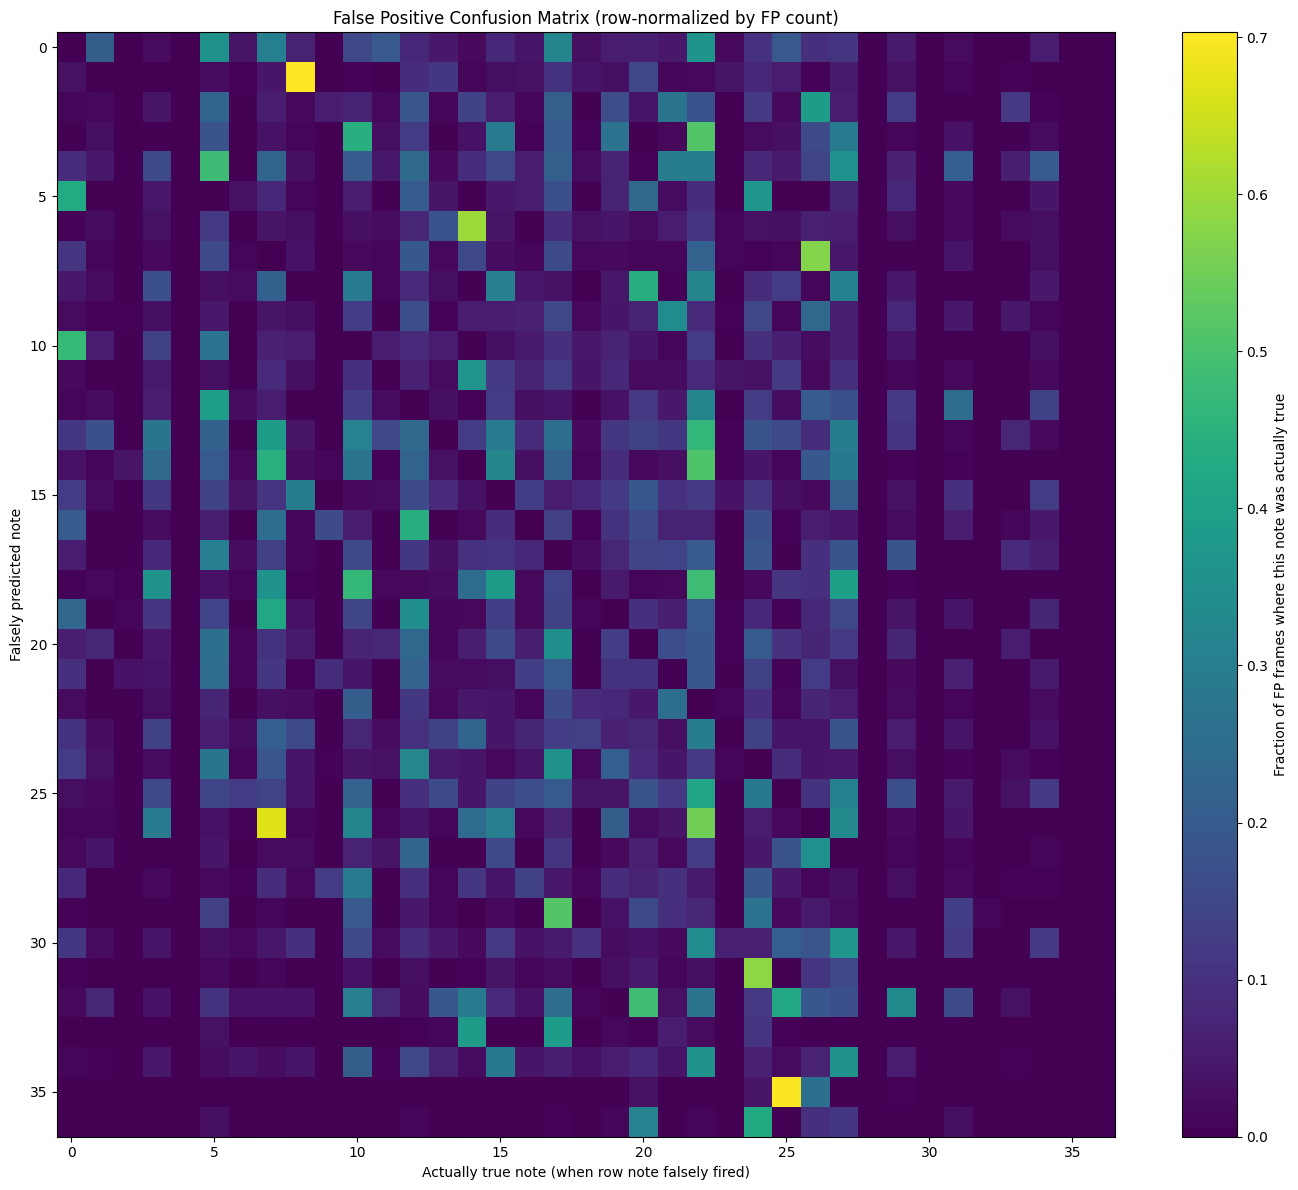


--- Top confusions for Regime 2 notes ---
Note 2 falsely fires most often when these are actually true: [(26, 0.388), (21, 0.27), (5, 0.227), (17, 0.213), (12, 0.187)]
Note 6 falsely fires most often when these are actually true: [(14, 0.6), (13, 0.177), (5, 0.119), (22, 0.106), (17, 0.09)]
Note 9 falsely fires most often when these are actually true: [(21, 0.341), (26, 0.235), (12, 0.168), (17, 0.15), (24, 0.15)]
Note 28 falsely fires most often when these are actually true: [(10, 0.291), (24, 0.191), (16, 0.137), (9, 0.124), (14, 0.111)]
Note 32 falsely fires most often when these are actually true: [(20, 0.486), (25, 0.42), (29, 0.337), (10, 0.302), (14, 0.286)]
Note 36 falsely fires most often when these are actually true: [(24, 0.426), (20, 0.311), (27, 0.111), (26, 0.097), (5, 0.028)]
Note  PosCount  MeanProbPos   MeanProbNeg   Precision   Recall    
0     12044     0.8253        0.0391        0.9331      0.8321    
1     1922      0.2624        0.0260        0.1838      0.1436 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Collect probs and true labels over multiple validation batches ---
all_probs = []
all_true = []

N_EVAL_BATCHES = 500  # adjust based on how much validation data you want to cover

for idx, (audio_batch, label_batch) in enumerate(dataset):
    if idx >= N_EVAL_BATCHES:
        break
    probs = cnn_model.predict(audio_batch, verbose=0)
    all_probs.append(probs)
    all_true.append(label_batch.numpy())

all_probs = np.concatenate(all_probs, axis=0)  # (N, 37)
all_true = np.concatenate(all_true, axis=0)    # (N, 37)

print("Collected shape:", all_probs.shape)

NUM_NOTES = 37

fig, axes = plt.subplots(7, 6, figsize=(24, 24))
axes = axes.flatten()

for note in range(NUM_NOTES):
    ax = axes[note]
    pos_mask = all_true[:, note] == 1
    neg_mask = all_true[:, note] == 0

    pos_probs = all_probs[pos_mask, note]
    neg_probs = all_probs[neg_mask, note]

    if len(pos_probs) > 0:
        ax.hist(pos_probs, bins=30, alpha=0.6, color='tab:green', label=f'pos (n={len(pos_probs)})', density=True)
    if len(neg_probs) > 0:
        ax.hist(neg_probs, bins=30, alpha=0.6, color='tab:red', label=f'neg (n={len(neg_probs)})', density=True)

    ax.axvline(0.6, color='black', linestyle='--', linewidth=1)
    ax.set_title(f"Note {note}", fontsize=10)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=6)

for j in range(NUM_NOTES, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('per_note_prob_histograms.png', dpi=100)
plt.show()

THRESHOLD = 0.6
pred_binary = (all_probs >= THRESHOLD).astype(int)

# False positive confusion: for each note i, when we falsely predict i,
# what was actually true (summed across all true-positive notes at that frame)
confusion = np.zeros((NUM_NOTES, NUM_NOTES))

for note_i in range(NUM_NOTES):
    fp_mask = (pred_binary[:, note_i] == 1) & (all_true[:, note_i] == 0)
    if fp_mask.sum() == 0:
        continue
    # sum of true labels across all notes, at the frames where note_i was a false positive
    true_at_fp = all_true[fp_mask].sum(axis=0)
    confusion[note_i] = true_at_fp / fp_mask.sum()  # normalize by number of FP instances

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(confusion, cmap='viridis', aspect='auto')
ax.set_xlabel("Actually true note (when row note falsely fired)")
ax.set_ylabel("Falsely predicted note")
ax.set_title("False Positive Confusion Matrix (row-normalized by FP count)")
plt.colorbar(im, ax=ax, label="Fraction of FP frames where this note was actually true")
plt.tight_layout()
plt.savefig('fp_confusion_matrix.png', dpi=100)
plt.show()

# Print the biggest confusions explicitly for your Regime 2 suspects
regime2_notes = [2, 6, 9, 28, 32, 36]
print("\n--- Top confusions for Regime 2 notes ---")
for note in regime2_notes:
    top_confused = np.argsort(confusion[note])[::-1][:5]
    print(f"Note {note} falsely fires most often when these are actually true: "
          f"{[(int(n), round(float(confusion[note][n]), 3)) for n in top_confused]}")
    
    from sklearn.metrics import precision_score, recall_score

print(f"{'Note':<6}{'PosCount':<10}{'MeanProbPos':<14}{'MeanProbNeg':<14}{'Precision':<12}{'Recall':<10}")
for note in range(NUM_NOTES):
    pos_mask = all_true[:, note] == 1
    neg_mask = all_true[:, note] == 0
    mean_pos = all_probs[pos_mask, note].mean() if pos_mask.sum() > 0 else float('nan')
    mean_neg = all_probs[neg_mask, note].mean() if neg_mask.sum() > 0 else float('nan')
    p = precision_score(all_true[:, note], pred_binary[:, note], zero_division=0)
    r = recall_score(all_true[:, note], pred_binary[:, note], zero_division=0)
    print(f"{note:<6}{int(pos_mask.sum()):<10}{mean_pos:<14.4f}{mean_neg:<14.4f}{p:<12.4f}{r:<10.4f}")

In [ ]:



string_layer_names = [f"chord_block_softmax_str{i}" for i in range(6)]

softmax_entropy_report(cnn_model, dataset.take(1), string_layer_names)
plot_active_neurons(cnn_model, dataset.take(1),active_threshold=0.15,batch_agg='mean')


for var in cnn_model.trainable_variables:
    var_id = getattr(var, 'path', var.name)
    if "freq_compress_conv2d" in var_id:
        print(var_id)

visualize_model_weights(cnn_model)

# print length of dataset
dataset_length = sum(1 for _ in dataset)
print(f"Dataset length: {dataset_length}")

#dataset=dataset.map(lambda path: fast_gpu_map(path, training=False)).take(100).prefetch(tf.data.AUTOTUNE)
#dataset = dataset.shuffle(BATCH_SIZE * 2).map(lambda path: fast_gpu_map(path, training=False), num_parallel_calls=tf.data.AUTOTUNE)
labels_true_all=[]
labels_pred_all=[]
total_tp=0
total_fp=0
total_fn=0

#Get the 7th tuple of the dataset (audio, label) and run a prediction

audio,label=None,None
element_idx=1
for idx, (audio_batch, label_batch) in enumerate(dataset):
    if idx == element_idx:
        print(f"Selected element index: {idx}")
        x = audio_batch
        y_true = label_batch
        break

#plot_all_layer_activations(cnn_model, x)
y_pred = cnn_model.predict(x)

for i in range(len(y_true)):
    true_notes = np.where(y_true[i] > 0.5)[0]
    pred_raw = y_pred[i]
    
    # Show top 10 highest predictions
    top10 = np.argsort(pred_raw)[-10:][::-1]
    
    print(f"\n--- Sample {i} ---")
    print(f"True notes: {true_notes}")
    print(f"Top 10 predictions:")
    for idx in top10:
        print(f"  note {idx}: {pred_raw[idx]:.4f} {'✓' if idx in true_notes else ''}")
    
    # Show prediction stats
    print(f"Max: {pred_raw.max():.4f}, Min: {pred_raw.min():.4f}, "
          f"Mean: {pred_raw.mean():.4f}, >0.5: {(pred_raw > 0.5).sum()}")
    # Prediction standard deviation
    print(f"Std Dev: {pred_raw.std():.4f}")

for n in range(1,7):
    dataset=filter_polyphony(dataset_orig.unbatch(),n,True,start_note=0,end_note=37,has_filtered_audio=True).batch(BATCH_SIZE,drop_remainder=True)#.take(10000).prefetch(tf.data.AUTOTUNE)

    for audio,label in dataset:
        # print("Audio shape:", audio.shape)
        pred=cnn_model.predict(audio,verbose=0)
        # print("Pred shape:", pred.shape)
        # print("Label shape:", label.shape)
        label=label.numpy()#.flatten()
        label=label[:,:37]
        pred=pred#.flatten()
        # print("flat Pred shape:", pred.shape)
        # print("flat Label shape:", label.shape)
        labels_true_all.append(label)
        labels_pred_all.append(pred)
        thresh=0.7
        label_active = label#[:88] # Assuming 88 notes
        pred_active = pred#[ :88]
        total_tp += np.sum((label_active == 1) & (pred_active > thresh),axis=0)
        #total_tp+=np.sum((label==1) & (pred>thresh))
        total_fp+=np.sum((label_active==0)&(pred_active>thresh),axis=0)
        total_fn+=np.sum((label_active==1)&(pred_active<=thresh),axis=0)


    print(f"polyphony: {n}")
    print("Total True Positives:", total_tp)
    print("Total False Positives:", total_fp)
    print("Total False Negatives:", total_fn)
    precision=total_tp/(total_tp+total_fp+1e-8)
    recall=total_tp/(total_tp+total_fn+1e-8)
    print("Precision:", precision)
    print("Recall:", recall)


# Run predictions on the first 1000 samples and collect stats
predictions = []
for audio, label in dataset:
    pred = cnn_model.predict(audio, verbose=0)
    predictions.append(pred)

#create a histogram of the predictions
predictions = np.concatenate(predictions, axis=0)
plt.figure(figsize=(10, 6))
plt.hist(predictions.flatten(), bins=100, color='steelblue', edgecolor='none')
plt.title('Histogram of Model Predictions (All Samples)')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("predictions_histogram.png", dpi=150)
plt.show()


NameError: name 'softmax_entropy_report' is not defined

In [ ]:
print("Length of labels_true_all:", len(labels_true_all))
labels_true=np.concatenate(labels_true_all,axis=0)
labels_pred=np.concatenate(labels_pred_all,axis=0)
labels_pred=(labels_pred>0.5).astype(np.float32)
print("Shape of labels true:",labels_true.shape)
#compute recall
tp=np.sum((labels_true==1) & (labels_pred==1),axis=0)

fp=np.sum((labels_true==0)&(labels_pred==1),axis=0)
fn=np.sum((labels_true==1)&(labels_pred==0),axis=0)
print("Shape of tp",tp.shape)

precision=tp/(tp+fp+1e-8)
print("precision:", precision)
recall=tp/(tp+fn+1e-8)
print("recall:", recall)
print("True Positives:", tp)
print("False Positives:", fp)

NameError: name 'labels_true_all' is not defined

In [ ]:
# # Convert lists to single arrays
# all_true = np.concatenate(labels_true_all, axis=0)[:, :88]
# all_pred = np.concatenate(labels_pred_all, axis=0)[:, :88]

# # Binary threshold for the plot
# all_pred_bin = (all_pred > 0.5).astype(np.float32)

# plt.figure(figsize=(15, 10))

# # Plot Ground Truth (Blue)
# plt.subplot(2, 1, 1)
# plt.imshow(all_true.T, aspect='auto', origin='lower', cmap='Blues', interpolation='nearest')
# plt.title("Ground Truth (Active MIDI Notes 0-87)")
# plt.ylabel("MIDI Note Index")

# # Plot Predictions (Red)
# plt.subplot(2, 1, 2)
# plt.imshow(all_pred_bin.T, aspect='auto', origin='lower', cmap='Reds', interpolation='nearest')
# plt.title("Model Predictions (Threshold 0.5)")
# plt.ylabel("MIDI Note Index")
# plt.xlabel("Time (Frames)")

# plt.tight_layout()
# plt.show()